In [1]:
import pandas as pd
import plotly.express as px
from pathlib import Path

# ============================
# CARREGAR TODOS OS CSVs
# ============================

results_path = Path("")

csv_files = list(results_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError("Nenhum CSV encontrado na pasta ../results")

dfs = []
for csv in csv_files:
    df_tmp = pd.read_csv(csv)
    df_tmp["source_file"] = csv.name  # opcional: rastrear origem
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)

# 🔧 garantir que erro é numérico
df["erro"] = pd.to_numeric(df["erro"], errors="coerce")

# ============================
# ORDENAR MODELOS
# ============================

order = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index
    .tolist()
)

# ============================
# MAPA DE CORES
# ============================

color_map = {
    "baseline_ultra":  "#EF553B",
    "shape_ultra":  "#EF553B",
    "tail_ultra":  "#EF553B",
    "divergence_ultra": "#EF553B",
    "qderiv_ultra": "#EF553B",
    "baseline_tails_01": "#EF553B",
    "DyS_hellinger": "#fc03d3",
    "DyS_topsoe": "#fc03d3",
    "QuaDapt_DyS": "#fc03d3",
    "baseline_lite": "#19D3F3",
    "mfe": "#19D3F3",
    "qderiv_lite": "#19D3F3",
    "MiniRocket": "#19D3F3",
    "tsfresh": "#19D3F3",
    "catch22": "#19D3F3",
    "divergence_lite": "#19D3F3",
    "tail_lite": "#19D3F3",
    "shape_lite": "#19D3F3"
}

# ============================
# PLOT
# ============================

fig = px.box(
    df,
    x="modelo",
    y="erro",
    category_orders={"modelo": order},
    points="all",
    color="modelo",
    color_discrete_map=color_map
)

fig.update_traces(
    jitter=0.35,
    marker=dict(size=4, opacity=0.6),
)

fig.update_layout(
    title="Comparação de erro entre modelos (ordenado do melhor ao pior)",
    xaxis_title="Modelo",
    yaxis_title="Erro absoluto |prev_pred − prev_real|",
    template="simple_white",
    width=950,
    height=450,
    showlegend=True
)

fig

In [2]:
import pandas as pd
import plotly.express as px
from pathlib import Path

# ============================
# CARREGAR TODOS OS CSVs
# ============================

results_path = Path("")

csv_files = list(results_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "Nenhum CSV encontrado"
    )

dfs = []

for csv in csv_files:

    df_tmp = pd.read_csv(csv)

    df_tmp["source_file"] = csv.name

    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)

# ============================
# LIMPEZA
# ============================

df["erro"] = pd.to_numeric(
    df["erro"],
    errors="coerce"
)

# ============================
# AGRUPAR TODOS OS MOSS
# ============================

df["grupo_modelo"] = df["modelo"]

df.loc[
    df["modelo"].str.contains(
        "MoSS",
        case=False,
        na=False
    ),
    "grupo_modelo"
] = "MoSS"

# ============================
# ORDEM DOS GRUPOS
# ============================

order = (
    df.groupby("grupo_modelo")["erro"]
    .median()
    .sort_values()
    .index
    .tolist()
)

# ============================
# CORES
# ============================

color_map = {
    "MoSS": "#19D3F3",
    "EMQ_BCTS": "#EF553B",
    "ClusterQuant": "#AB63FA"
}

# ============================
# PLOT
# ============================

fig = px.box(
    df,
    x="grupo_modelo",
    y="erro",
    color="grupo_modelo",
    category_orders={
        "grupo_modelo": order
    },
    color_discrete_map=color_map,
    points="all"
)

fig.update_traces(
    jitter=0.35,
    marker=dict(
        size=4,
        opacity=0.5
    )
)

fig.update_layout(
    title=(
        "Comparação entre grupos de modelos"
    ),
    xaxis_title="Grupo",
    yaxis_title=(
        "Erro absoluto |prev_pred − prev_real|"
    ),
    template="simple_white",
    width=900,
    height=500,
    showlegend=False
)

fig.show()

# ============================
# SALVAR HTML
# ============================

#fig.write_html(
#    "comparacao_grupos.html"
#)

print(
    "✅ HTML salvo em comparacao_grupos.html"
)

✅ HTML salvo em comparacao_grupos.html


In [3]:
# ============================
# TABELA DE MEDIANAS
# ============================

tabela_mediana = (
    df.groupby(
        ["dataset", "grupo_modelo"]
    )["erro"]
    .median()
    .reset_index()
)

# pivotar para ficar bonito
tabela_mediana = tabela_mediana.pivot(
    index="dataset",
    columns="grupo_modelo",
    values="erro"
)

# ordenar datasets pela melhor mediana do MoSS
if "MoSS" in tabela_mediana.columns:
    tabela_mediana = tabela_mediana.sort_values(
        by="MoSS"
    )

print("\n===== MEDIANA POR DATASET =====\n")

print(
    tabela_mediana.round(4)
)

# salvar CSV
#tabela_mediana.to_csv(
#    "medianas_por_dataset.csv"
#)

print(
    "\n✅ Tabela salva em medianas_por_dataset.csv"
)


===== MEDIANA POR DATASET =====

grupo_modelo          AC      CC  ClusterQuant     EMQ  EMQ_BCTS      FM  \
dataset                                                                    
letter            0.0442  0.0438        0.0373  0.0463    0.0465  0.0367   
isolet            0.0447  0.0438        0.0403  0.0481    0.0483  0.0350   
chess             0.0671  0.0560        0.0638  0.0691    0.0687  0.0621   
shuttle           0.0121  0.0300        0.1303  0.0087    0.0089  0.0261   
digits            0.0615  0.0620        0.0635  0.0685    0.0693  0.0626   
hand_digits       0.0548  0.0540        0.0549  0.0565    0.0565  0.0584   
abalone           0.0990  0.0864        0.0768  0.0883    0.0887  0.1263   
poker_hand        0.1825  0.1825        0.1711  0.1556    0.1536  0.1787   
dry-bean          0.0918  0.0857        0.0773  0.0921    0.0915  0.0891   
nursery           0.0786  0.0800        0.1523  0.0877    0.0888  0.1232   
wine-quality      0.1254  0.1320        0.1548  0.0898

In [4]:
import pandas as pd
import plotly.express as px

# =========================================================
# LOAD
# =========================================================
results_path = Path("")

csv_files = list(results_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError("Nenhum CSV encontrado na pasta ../results")

dfs = []
for csv in csv_files:
    df_tmp = pd.read_csv(csv)
    df_tmp["source_file"] = csv.name  # opcional: rastrear origem
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)

# 🔧 garantir que erro é numérico
df["erro"] = pd.to_numeric(df["erro"], errors="coerce")

# =========================================================
# AGREGAÇÃO (modelo × dataset)
# 👉 troque mean por median se quiser
# =========================================================
df_agg = (
    df
    .groupby(["modelo", "dataset"], as_index=False)
    .agg(erro_mean=("erro", "mean"))
)

# =========================================================
# ORDEM DOS MODELOS (melhor → pior)
# =========================================================
order = (
    df_agg
    .groupby("modelo")["erro_mean"]
    .median()
    .sort_values()
    .index
    .tolist()
)


# =========================================================
# LINEPLOT
# =========================================================
fig = px.line(
    df_agg,
    x="dataset",
    y="erro_mean",
    color="modelo",
    category_orders={"modelo": order},
    markers=True
)

fig.update_layout(
    title="Erro médio por dataset (lineplot)",
    xaxis_title="Dataset",
    yaxis_title="Erro médio |prev_pred − prev_real|",
    template="simple_white",
    width=1100,
    height=500,
)

fig.update_traces(
    marker=dict(size=6),
    line=dict(width=2)
)

fig


===== CSV LOADED =====
    dataset    modelo  n_classes_original      erro
0  dry-bean       EMQ                   7  0.043832
1  dry-bean  EMQ_BCTS                   7  0.045506
2  dry-bean        CC                   7  0.042857
3  dry-bean       PCC                   7  0.040686
4  dry-bean        AC                   7  0.042982

===== MODELOS RESTANTES =====
['AC', 'CC', 'EMQ', 'FM', 'KDEyML', 'MoSS_CALIBRATED', 'PAC', 'PCC', 'PWK']

===== AVERAGE RANK =====
            modelo  rank_dataset
0              PCC      2.833333
1  MoSS_CALIBRATED      3.458333
2              PWK      3.583333
3               CC      4.687500
4           KDEyML      5.125000
5              PAC      6.166667
6               FM      6.250000
7              EMQ      6.375000
8               AC      6.520833


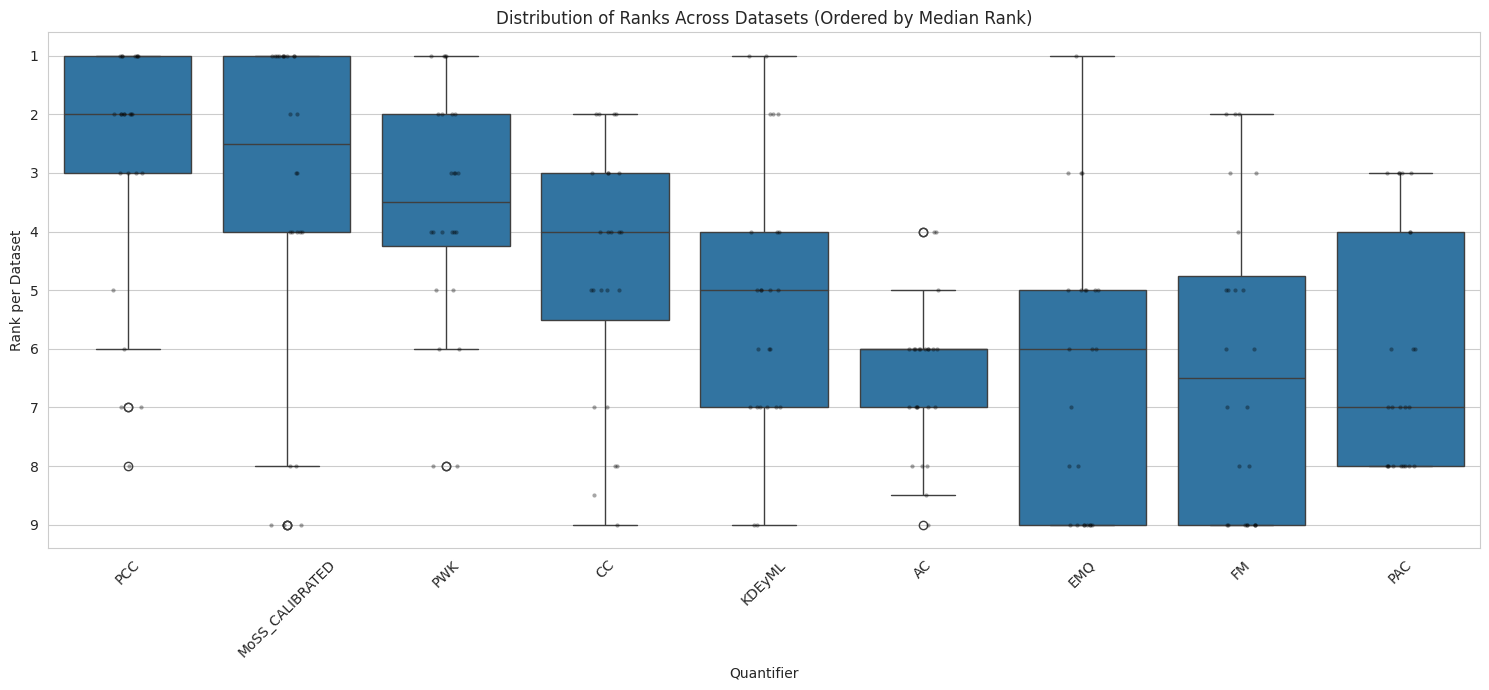

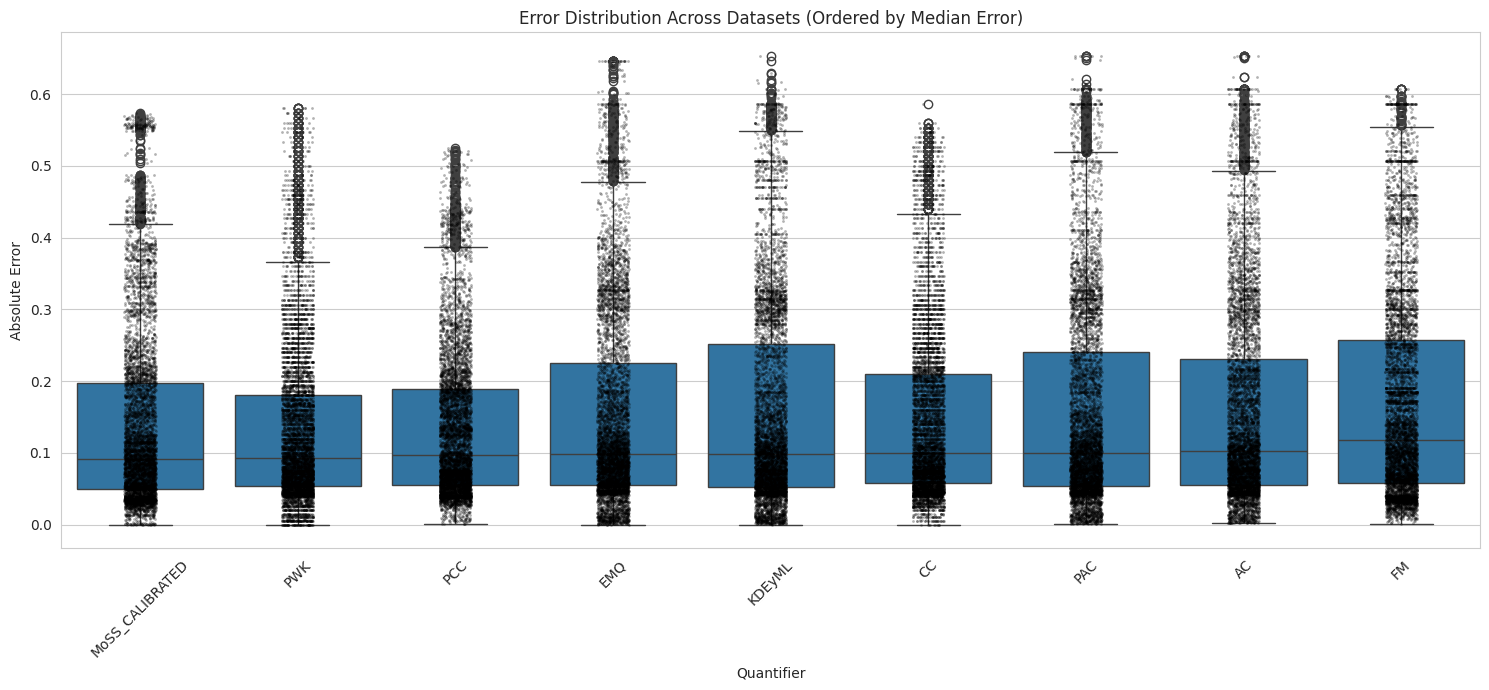


===== GLOBAL MEAN ERROR =====
            modelo  mean_error
0              PWK    0.130409
1              PCC    0.134450
2  MoSS_CALIBRATED    0.139141
3               CC    0.146618
4              EMQ    0.153458
5              PAC    0.157139
6           KDEyML    0.157483
7               AC    0.159882
8               FM    0.171418

===== GLOBAL MEDIAN ERROR =====
            modelo  median_error
0  MoSS_CALIBRATED      0.091705
1              PWK      0.093333
2              PCC      0.096465
3              EMQ      0.098339
4           KDEyML      0.098633
5               CC      0.100000
6              PAC      0.100530
7               AC      0.102207
8               FM      0.118195

✅ ANALYSIS FINISHED

Arquivos gerados:
 - average_rank_filtered.csv
 - global_mean_error_filtered.csv
 - global_median_error_filtered.csv
 - rank_boxplot_filtered.png
 - error_boxplot_filtered.png


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "exp_results.csv"

# ============================================================
# STYLE
# ============================================================

sns.set_style("whitegrid")

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\n===== CSV LOADED =====")
print(df.head())

# ============================================================
# UNIFICAR TODOS OS MOSS
# ============================================================

df["modelo"] = df["modelo"].replace(
    to_replace=r"MoSS_\d+_CALIBRATED",
    value="MoSS_CALIBRATED",
    regex=True
)

# ============================================================
# REMOVER MODELOS ESPECÍFICOS
# ============================================================

modelos_remover = [
    "KDEyHD",
    "KDEyCS",
    "EMQ_BCTS",
    "ClusterQuant"
]

df = df[~df["modelo"].isin(modelos_remover)]

print("\n===== MODELOS RESTANTES =====")
print(sorted(df["modelo"].unique()))

# ============================================================
# MÉDIA POR DATASET
# ============================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# RANK DENTRO DE CADA DATASET
# ============================================================

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

# ============================================================
# AVERAGE RANK FINAL
# ============================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .mean()
    .sort_values()
    .reset_index()
)

print("\n===== AVERAGE RANK =====")
print(avg_rank)

# ============================================================
# SALVAR AVG RANK
# ============================================================

#avg_rank.to_csv(
#    "average_rank_filtered.csv",
#    index=False
#)

# ============================================================
# ORDEM PELA MEDIANA DOS RANKS
# ============================================================

ordem_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS RANKS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank
)

sns.stripplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank,
    color="black",
    alpha=0.35,
    size=3
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Rank per Dataset")

plt.title(
    "Distribution of Ranks Across Datasets "
    "(Ordered by Median Rank)"
)

# rank menor = melhor
plt.gca().invert_yaxis()

plt.tight_layout()

#plt.savefig(
#    "rank_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# ORDEM PELA MEDIANA DOS ERROS
# ============================================================

ordem_erro = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS ERROS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro
)

sns.stripplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro,
    color="black",
    alpha=0.30,
    size=2
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Absolute Error")

plt.title(
    "Error Distribution Across Datasets "
    "(Ordered by Median Error)"
)

plt.tight_layout()

#plt.savefig(
#    "error_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# MELHOR MODELO GLOBAL RESTANTE
# ============================================================

global_mean_error = (
    df.groupby("modelo")["erro"]
    .mean()
    .sort_values()
    .reset_index()
)

global_mean_error.columns = [
    "modelo",
    "mean_error"
]

print("\n===== GLOBAL MEAN ERROR =====")
print(global_mean_error)

# ============================================================
# MEDIANA GLOBAL DOS ERROS
# ============================================================

global_median_error = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .reset_index()
)

global_median_error.columns = [
    "modelo",
    "median_error"
]

print("\n===== GLOBAL MEDIAN ERROR =====")
print(global_median_error)

# ============================================================
# SALVAR RESULTADOS
# ============================================================

#global_mean_error.to_csv(
#    "global_mean_error_filtered.csv",
#    index=False
#)

#global_median_error.to_csv(
#    "global_median_error_filtered.csv",
#    index=False
#)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n✅ ANALYSIS FINISHED")

print("\nArquivos gerados:")

print(" - average_rank_filtered.csv")
print(" - global_mean_error_filtered.csv")
print(" - global_median_error_filtered.csv")

print(" - rank_boxplot_filtered.png")
print(" - error_boxplot_filtered.png")


===== CSV LOADED =====
    dataset    modelo  n_classes_original      erro
0  dry-bean       EMQ                   7  0.043832
1  dry-bean  EMQ_BCTS                   7  0.045506
2  dry-bean        CC                   7  0.042857
3  dry-bean       PCC                   7  0.040686
4  dry-bean        AC                   7  0.042982

Total original datasets: 24

===== MODELOS RESTANTES =====
['AC', 'CC', 'EMQ', 'FM', 'KDEyML', 'MoSS_CALIBRATED', 'PAC', 'PCC', 'PWK']

Total remaining models: 9

Datasets completos restantes: 24

✅ Todos os datasets possuem todos os modelos restantes.

===== AVERAGE RANK =====
            modelo  rank_dataset
0              PCC      2.833333
1  MoSS_CALIBRATED      3.458333
2              PWK      3.583333
3               CC      4.687500
4           KDEyML      5.125000
5              PAC      6.166667
6               FM      6.250000
7              EMQ      6.375000
8               AC      6.520833


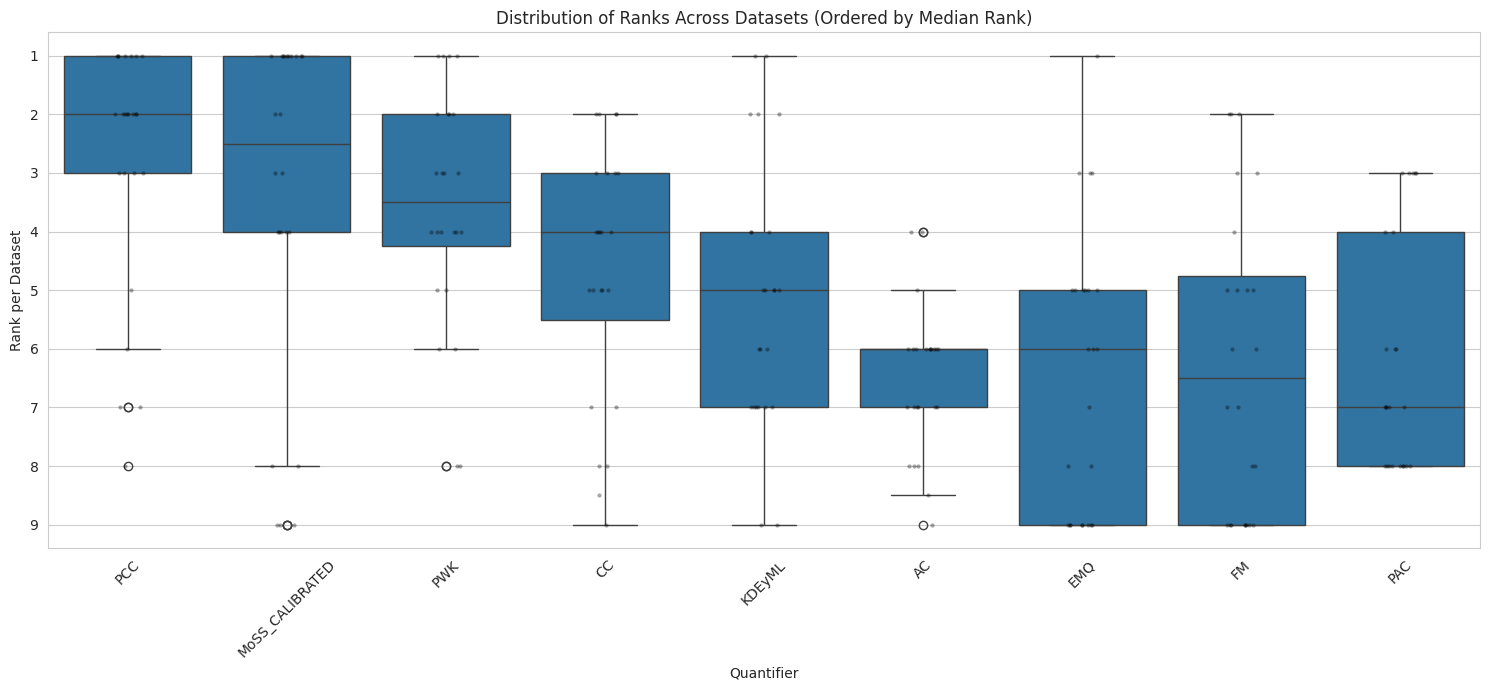

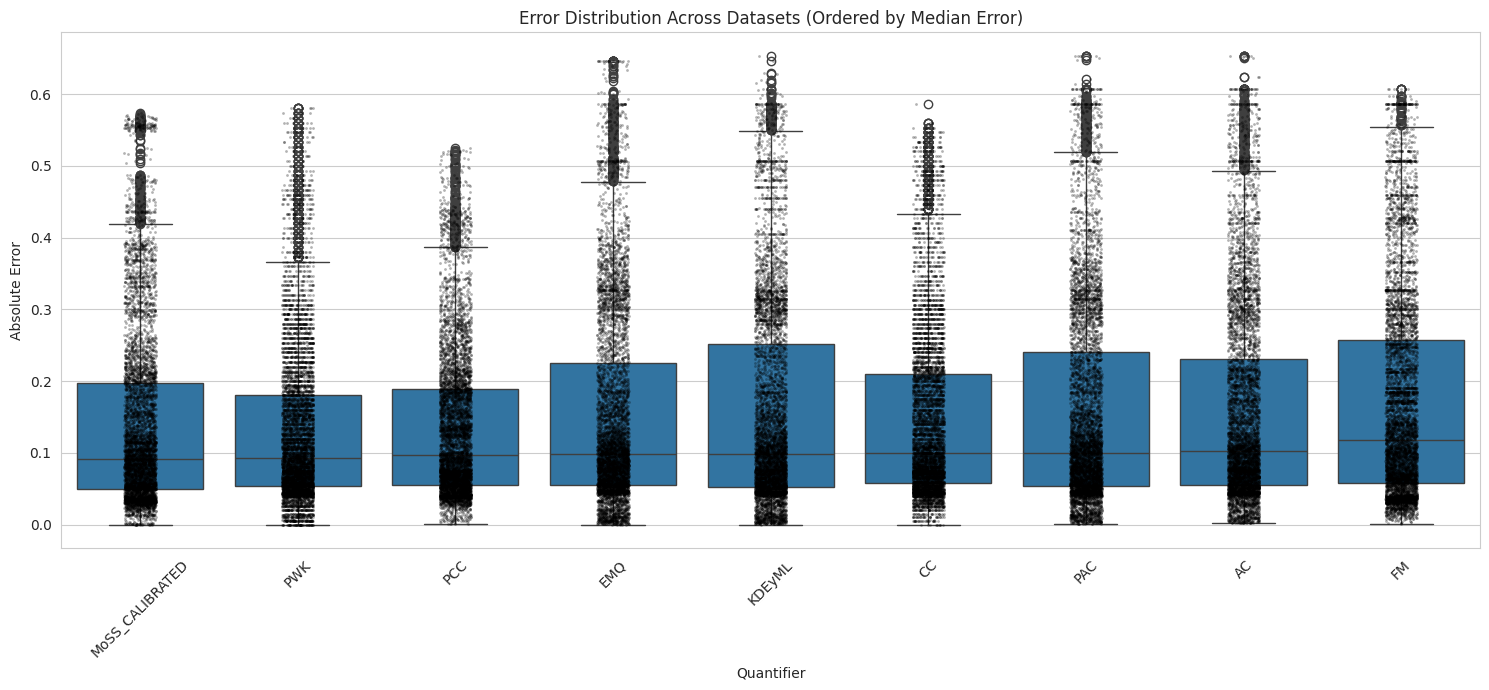


===== GLOBAL MEAN ERROR =====
            modelo  mean_error
0              PWK    0.130409
1              PCC    0.134450
2  MoSS_CALIBRATED    0.139141
3               CC    0.146618
4              EMQ    0.153458
5              PAC    0.157139
6           KDEyML    0.157483
7               AC    0.159882
8               FM    0.171418

===== GLOBAL MEDIAN ERROR =====
            modelo  median_error
0  MoSS_CALIBRATED      0.091705
1              PWK      0.093333
2              PCC      0.096465
3              EMQ      0.098339
4           KDEyML      0.098633
5               CC      0.100000
6              PAC      0.100530
7               AC      0.102207
8               FM      0.118195

===== RESULTS TABLE =====
modelo                                     AC        CC       EMQ        FM  \
dataset          n_classes_original                                           
academic-success 3                   0.295254  0.304044  0.294675  0.396606   
cmc              3              

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "exp_results.csv"

# ============================================================
# STYLE
# ============================================================

sns.set_style("whitegrid")

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\n===== CSV LOADED =====")
print(df.head())

# ============================================================
# UNIFICAR TODOS OS MOSS
# ============================================================

df["modelo"] = df["modelo"].replace(
    to_replace=r"MoSS_\d+_CALIBRATED",
    value="MoSS_CALIBRATED",
    regex=True
)

# ============================================================
# DATASETS ORIGINAIS
# ============================================================

all_datasets = sorted(df["dataset"].unique())

print(f"\nTotal original datasets: {len(all_datasets)}")

# ============================================================
# REMOVER MODELOS
# ============================================================

modelos_remover = [
    "KDEyHD",
    "KDEyCS",
    "EMQ_BCTS",
    "ClusterQuant"
]

df_filtered = df[
    ~df["modelo"].isin(modelos_remover)
].copy()

# ============================================================
# MODELOS RESTANTES
# ============================================================

remaining_models = sorted(
    df_filtered["modelo"].unique()
)

print("\n===== MODELOS RESTANTES =====")
print(remaining_models)

print(f"\nTotal remaining models: {len(remaining_models)}")

# ============================================================
# GARANTIR DATASETS COMPLETOS
# ============================================================
# Mantém apenas datasets que possuem TODOS os
# modelos restantes
# ============================================================

dataset_model_count = (
    df_filtered.groupby("dataset")["modelo"]
    .nunique()
)

valid_datasets = dataset_model_count[
    dataset_model_count == len(remaining_models)
].index

df = df_filtered[
    df_filtered["dataset"].isin(valid_datasets)
].copy()

print(f"\nDatasets completos restantes: {len(valid_datasets)}")

missing_datasets = set(all_datasets) - set(valid_datasets)

if len(missing_datasets) > 0:
    print("\n⚠️ DATASETS REMOVIDOS (incompletos):")
    for d in sorted(missing_datasets):
        print(d)

# ============================================================
# CHECAGEM FINAL
# ============================================================

final_check = (
    df.groupby("dataset")["modelo"]
    .nunique()
)

assert (final_check == len(remaining_models)).all()

print("\n✅ Todos os datasets possuem todos os modelos restantes.")

# ============================================================
# MÉDIA POR DATASET
# ============================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# RANK DENTRO DE CADA DATASET
# ============================================================

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

# ============================================================
# AVERAGE RANK FINAL
# ============================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .mean()
    .sort_values()
    .reset_index()
)

print("\n===== AVERAGE RANK =====")
print(avg_rank)

# ============================================================
# SALVAR AVG RANK
# ============================================================

#avg_rank.to_csv(
#    "average_rank_filtered.csv",
#    index=False
#)

# ============================================================
# ORDEM PELA MEDIANA DOS RANKS
# ============================================================

ordem_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS RANKS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank
)

sns.stripplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank,
    color="black",
    alpha=0.35,
    size=3
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Rank per Dataset")

plt.title(
    "Distribution of Ranks Across Datasets "
    "(Ordered by Median Rank)"
)

# rank menor = melhor
plt.gca().invert_yaxis()

plt.tight_layout()

#plt.savefig(
#    "rank_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# ORDEM PELA MEDIANA DOS ERROS
# ============================================================

ordem_erro = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS ERROS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro
)

sns.stripplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro,
    color="black",
    alpha=0.30,
    size=2
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Absolute Error")

plt.title(
    "Error Distribution Across Datasets "
    "(Ordered by Median Error)"
)

plt.tight_layout()

#plt.savefig(
#    "error_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# MELHOR MODELO GLOBAL RESTANTE
# ============================================================

global_mean_error = (
    df.groupby("modelo")["erro"]
    .mean()
    .sort_values()
    .reset_index()
)

global_mean_error.columns = [
    "modelo",
    "mean_error"
]

print("\n===== GLOBAL MEAN ERROR =====")
print(global_mean_error)

# ============================================================
# MEDIANA GLOBAL DOS ERROS
# ============================================================

global_median_error = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .reset_index()
)

global_median_error.columns = [
    "modelo",
    "median_error"
]

print("\n===== GLOBAL MEDIAN ERROR =====")
print(global_median_error)

# ============================================================
# TABELA FINAL COM NÚMERO DE CLASSES
# ============================================================
# ESTE BLOCO ASSUME QUE EXISTE UMA COLUNA:
#   - "n_classes"
# OU:
#   - "classes"
#
# Se o nome for diferente, apenas troque abaixo.
# ============================================================

N_CLASSES_COLUMN = "n_classes_original"

# média por dataset/modelo
dataset_table = (
    df.groupby(
        ["dataset", N_CLASSES_COLUMN, "modelo"]
    )["erro"]
    .mean()
    .reset_index()
)

# pivot table
results_table = dataset_table.pivot_table(
    index=["dataset", N_CLASSES_COLUMN],
    columns="modelo",
    values="erro"
)

# ordenar datasets pelo número de classes
results_table = results_table.sort_index(level=1)

# arredondar
results_table = results_table.round(6)

print("\n===== RESULTS TABLE =====")
print(results_table)

# salvar csv
results_table.to_csv(
    "results_by_dataset_and_classes.csv"
)

# ============================================================
# TABELA COM RANKS POR DATASET
# ============================================================

rank_table = (
    dataset_mean.pivot_table(
        index="dataset",
        columns="modelo",
        values="rank_dataset"
    )
    .round(3)
)

print("\n===== RANK TABLE =====")
print(rank_table)

#rank_table.to_csv(
#    "rank_table_per_dataset.csv"
#)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n✅ ANALYSIS FINISHED")

print("\nArquivos gerados:")

print(" - average_rank_filtered.csv")
print(" - global_mean_error_filtered.csv")
print(" - global_median_error_filtered.csv")

print(" - results_by_dataset_and_classes.csv")
print(" - rank_table_per_dataset.csv")

print(" - rank_boxplot_filtered.png")
print(" - error_boxplot_filtered.png")

In [9]:
import pandas as pd

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv("exp_results.csv")

# ============================================================
# TOTAL DE DATASETS
# ============================================================

datasets = sorted(df["dataset"].unique())

print("\n===== DATASETS =====")

for d in datasets:
    print(d)

print("\n====================")
print(f"TOTAL DATASETS: {len(datasets)}")


===== DATASETS =====
abalone
academic-success
chess
cmc
connect-4
digits
dry-bean
hand_digits
hcv
image_seg
isolet
letter
mhr
molecular
nursery
obesity
page_block
phishing
poker_hand
satellite
shuttle
waveform-v1
wine-quality
yeast

TOTAL DATASETS: 24
